Classification

CELL 1 — Install & Import

In [4]:
# Install if needed
# pip install scikit-learn pandas numpy matplotlib seaborn scipy scikit-learn-extra

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              confusion_matrix, classification_report,
                              roc_curve, auc, roc_auc_score)

# Classification Models
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.tree            import DecisionTreeClassifier

# Clustering Models
from sklearn.cluster         import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition   import PCA
from sklearn.preprocessing   import MinMaxScaler

# Save path
MODELS_PATH = r"C:\Users\ABHINAV\Desktop\Heart_PA\models"
os.makedirs(MODELS_PATH, exist_ok=True)

print("✅ All libraries loaded!")
print(f"✅ Models path: {MODELS_PATH}")

✅ All libraries loaded!
✅ Models path: C:\Users\ABHINAV\Desktop\Heart_PA\models


CELL 2 — Load & Explore Dataset


In [6]:
# Load dataset
df = pd.read_csv(r"C:\Users\ABHINAV\Desktop\Heart_PA\heart.csv")

print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Shape         : {df.shape}")
print(f"Rows          : {df.shape[0]}")
print(f"Columns       : {df.shape[1]}")
print(f"\nTarget Column : HeartDisease")
print(f"\nClass Distribution:")
print(df['HeartDisease'].value_counts())
print(f"\nMissing Values:")
print(df.isnull().sum())
print(f"\nData Types:")
print(df.dtypes)
print(f"\nFirst 5 rows:")
df.head()

DATASET OVERVIEW
Shape         : (918, 12)
Rows          : 918
Columns       : 12

Target Column : HeartDisease

Class Distribution:
HeartDisease
1    508
0    410
Name: count, dtype: int64

Missing Values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Data Types:
Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object

First 5 rows:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


CELL 3 — Data Preprocessing

In [7]:
# One-hot encode categorical columns
df_encoded = pd.get_dummies(df, columns=[
    'Sex', 'ChestPainType', 'RestingECG',
    'ExerciseAngina', 'ST_Slope'
])

# Features and Target
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

print("Feature columns (20 total):")
for i, col in enumerate(X.columns):
    print(f"  {i+1:2}. {col}")

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

# Train-Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Standard Scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\nTrain samples : {X_train.shape[0]}")
print(f"Test  samples : {X_test.shape[0]}")

# Save scaler and feature columns
with open(os.path.join(MODELS_PATH, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

with open(os.path.join(MODELS_PATH, 'feature_columns.pkl'), 'wb') as f:
    pickle.dump(list(X.columns), f)

print("\n✅ Scaler saved!")
print("✅ Feature columns saved!")

Feature columns (20 total):
   1. Age
   2. RestingBP
   3. Cholesterol
   4. FastingBS
   5. MaxHR
   6. Oldpeak
   7. Sex_F
   8. Sex_M
   9. ChestPainType_ASY
  10. ChestPainType_ATA
  11. ChestPainType_NAP
  12. ChestPainType_TA
  13. RestingECG_LVH
  14. RestingECG_Normal
  15. RestingECG_ST
  16. ExerciseAngina_N
  17. ExerciseAngina_Y
  18. ST_Slope_Down
  19. ST_Slope_Flat
  20. ST_Slope_Up

X shape: (918, 20)
y shape: (918,)

Train samples : 734
Test  samples : 184

✅ Scaler saved!
✅ Feature columns saved!


CELL 4 — Helper Functions

In [8]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te,
                   scaled=True):
    """Train, evaluate and return all metrics"""

    Xtr = X_tr if not scaled else X_tr
    Xte = X_te if not scaled else X_te

    model.fit(Xtr, y_tr)
    y_pred = model.predict(Xte)

    # Metrics
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec  = recall_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred)

    # ROC AUC
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(Xte)[:, 1]
    else:
        y_prob = model.decision_function(Xte)
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())

    roc = roc_auc_score(y_te, y_prob)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc*100:.2f}%")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {roc:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_te, y_pred,
          target_names=['No Disease', 'Heart Disease']))

    return {
        'Model'    : name,
        'Accuracy' : round(acc * 100, 2),
        'Precision': round(prec, 4),
        'Recall'   : round(rec, 4),
        'F1_Score' : round(f1, 4),
        'ROC_AUC'  : round(roc, 4),
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
        'model'    : model
    }


def plot_confusion_matrix(y_te, y_pred, title, color='Blues'):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap=color,
                xticklabels=['No Disease', 'Heart Disease'],
                yticklabels=['No Disease', 'Heart Disease'],
                linewidths=1, linecolor='white',
                annot_kws={"size": 14})
    plt.title(f'Confusion Matrix — {title}',
              fontsize=13, fontweight='bold', pad=12)
    plt.ylabel('Actual',    fontsize=11)
    plt.xlabel('Predicted', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'cm_{title.replace(" ","_")}.png', dpi=150)
    plt.show()
    plt.close()

    TP = cm[1][1]; TN = cm[0][0]
    FP = cm[0][1]; FN = cm[1][0]
    print(f"  TP={TP}  TN={TN}  FP={FP}  FN={FN}")


print("✅ Helper functions ready!")

✅ Helper functions ready!


CELL 5 — Model 1: Logistic Regression

🔵 Training Logistic Regression...

  Logistic Regression
  Accuracy  : 88.59%
  Precision : 0.8716
  Recall    : 0.9314
  F1-Score  : 0.9005
  ROC-AUC   : 0.9295

  Classification Report:
               precision    recall  f1-score   support

   No Disease       0.91      0.83      0.87        82
Heart Disease       0.87      0.93      0.90       102

     accuracy                           0.89       184
    macro avg       0.89      0.88      0.88       184
 weighted avg       0.89      0.89      0.89       184



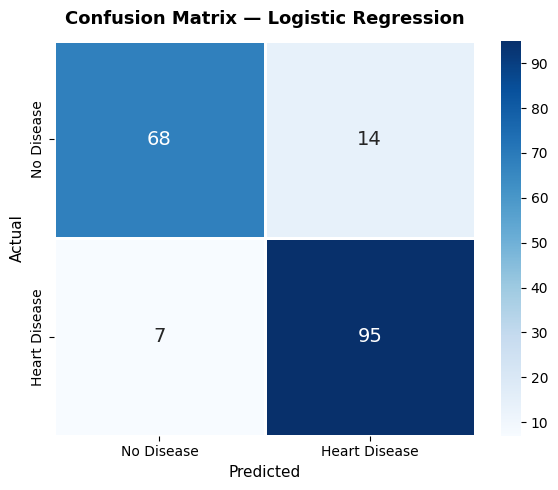

  TP=95  TN=68  FP=14  FN=7
✅ Logistic Regression model saved!


In [9]:
print("🔵 Training Logistic Regression...")

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=1.0
)

lr_results = evaluate_model(
    'Logistic Regression',
    lr_model,
    X_train_scaled, X_test_scaled,
    y_train, y_test
)

plot_confusion_matrix(
    y_test, lr_results['y_pred'],
    'Logistic Regression', 'Blues'
)

# Save model
with open(os.path.join(MODELS_PATH, 'logistic_model.pkl'), 'wb') as f:
    pickle.dump(lr_model, f)
print("✅ Logistic Regression model saved!")

CELL 6 — Model 2: Random Forest


🌲 Training Random Forest...

  Random Forest
  Accuracy  : 89.13%
  Precision : 0.8942
  Recall    : 0.9118
  F1-Score  : 0.9029
  ROC-AUC   : 0.9319

  Classification Report:
               precision    recall  f1-score   support

   No Disease       0.89      0.87      0.88        82
Heart Disease       0.89      0.91      0.90       102

     accuracy                           0.89       184
    macro avg       0.89      0.89      0.89       184
 weighted avg       0.89      0.89      0.89       184



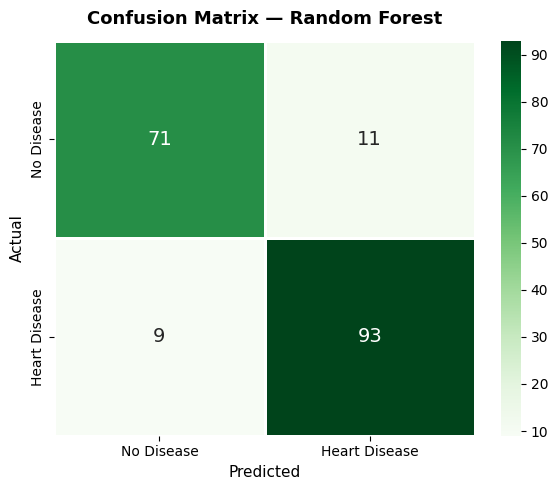

  TP=93  TN=71  FP=11  FN=9


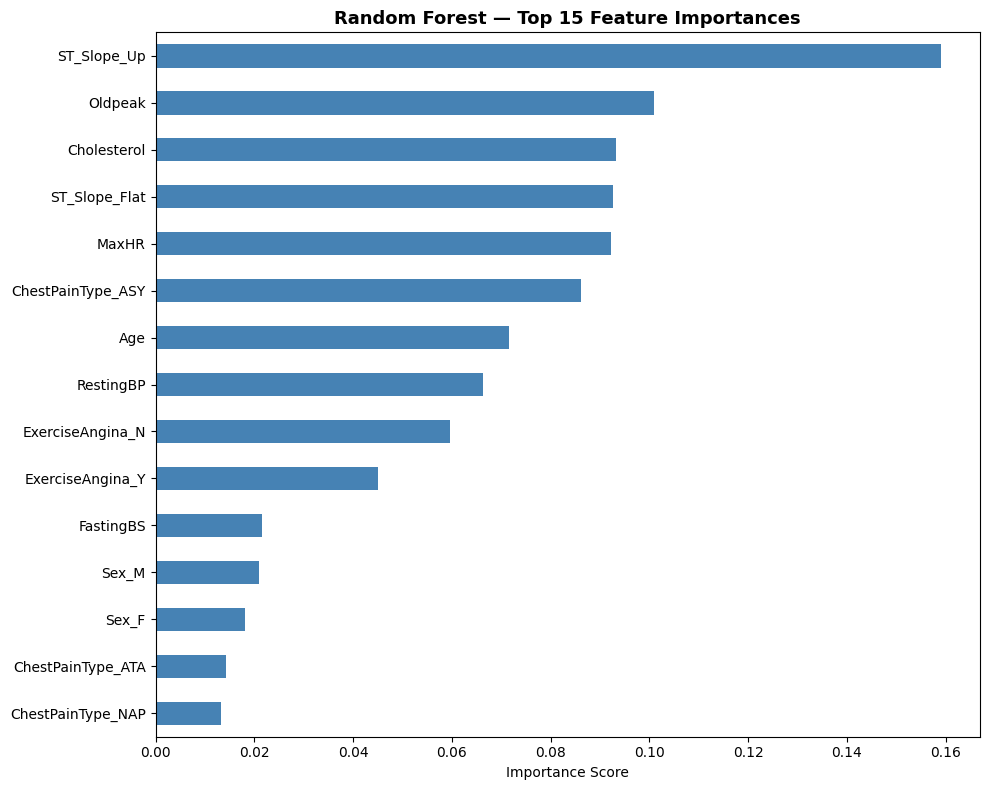

✅ Random Forest model saved!


In [10]:
print("🌲 Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_results = evaluate_model(
    'Random Forest',
    rf_model,
    X_train_scaled, X_test_scaled,
    y_train, y_test
)

plot_confusion_matrix(
    y_test, rf_results['y_pred'],
    'Random Forest', 'Greens'
)

# Feature Importance Plot
feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
feat_imp.tail(15).plot(kind='barh', color='steelblue')
plt.title('Random Forest — Top 15 Feature Importances',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150)
plt.show()
plt.close()

# Save model
with open(os.path.join(MODELS_PATH, 'rf_model.pkl'), 'wb') as f:
    pickle.dump(rf_model, f)
print("✅ Random Forest model saved!")

 CELL 7 — Model 3: SVM

🔴 Training SVM...

  SVM
  Accuracy  : 88.59%
  Precision : 0.8716
  Recall    : 0.9314
  F1-Score  : 0.9005
  ROC-AUC   : 0.9420

  Classification Report:
               precision    recall  f1-score   support

   No Disease       0.91      0.83      0.87        82
Heart Disease       0.87      0.93      0.90       102

     accuracy                           0.89       184
    macro avg       0.89      0.88      0.88       184
 weighted avg       0.89      0.89      0.89       184



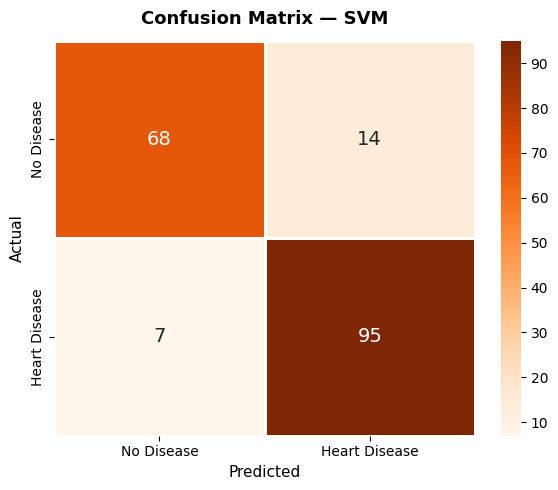

  TP=95  TN=68  FP=14  FN=7
✅ SVM model saved!


In [11]:
print("🔴 Training SVM...")

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,   # ← Required for ROC curve
    random_state=42
)

svm_results = evaluate_model(
    'SVM',
    svm_model,
    X_train_scaled, X_test_scaled,
    y_train, y_test
)

plot_confusion_matrix(
    y_test, svm_results['y_pred'],
    'SVM', 'Oranges'
)

# Save model
with open(os.path.join(MODELS_PATH, 'svm_model.pkl'), 'wb') as f:
    pickle.dump(svm_model, f)
print("✅ SVM model saved!")

CELL 8 — Model 4: KNN

🟡 Training KNN...


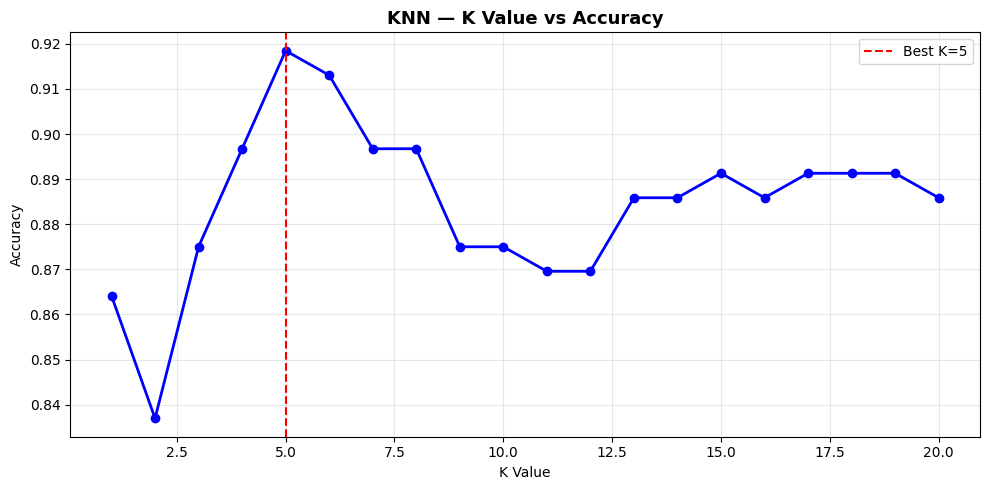

Best K = 5

  KNN
  Accuracy  : 91.85%
  Precision : 0.8991
  Recall    : 0.9608
  F1-Score  : 0.9289
  ROC-AUC   : 0.9252

  Classification Report:
               precision    recall  f1-score   support

   No Disease       0.95      0.87      0.90        82
Heart Disease       0.90      0.96      0.93       102

     accuracy                           0.92       184
    macro avg       0.92      0.91      0.92       184
 weighted avg       0.92      0.92      0.92       184



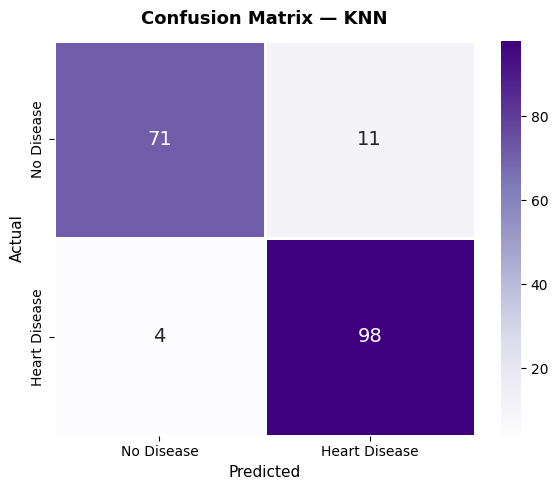

  TP=98  TN=71  FP=11  FN=4
✅ KNN model saved!


In [12]:
print("🟡 Training KNN...")

# Find best K
k_scores = []
k_range  = range(1, 21)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    k_scores.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

# Plot K vs Accuracy
plt.figure(figsize=(10, 5))
plt.plot(k_range, k_scores, 'bo-', linewidth=2, markersize=6)
plt.axvline(x=k_scores.index(max(k_scores))+1,
            color='red', linestyle='--',
            label=f'Best K={k_scores.index(max(k_scores))+1}')
plt.title('KNN — K Value vs Accuracy',
          fontsize=13, fontweight='bold')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('knn_k_vs_accuracy.png', dpi=150)
plt.show()
plt.close()

best_k   = k_scores.index(max(k_scores)) + 1
print(f"Best K = {best_k}")

knn_model = KNeighborsClassifier(n_neighbors=best_k)

knn_results = evaluate_model(
    'KNN',
    knn_model,
    X_train_scaled, X_test_scaled,
    y_train, y_test
)

plot_confusion_matrix(
    y_test, knn_results['y_pred'],
    'KNN', 'Purples'
)

# Save model
with open(os.path.join(MODELS_PATH, 'knn_model.pkl'), 'wb') as f:
    pickle.dump(knn_model, f)
print("✅ KNN model saved!")

CELL 9 — Model 5: Decision Tree

🟢 Training Decision Tree...

  Decision Tree
  Accuracy  : 79.89%
  Precision : 0.8218
  Recall    : 0.8137
  F1-Score  : 0.8177
  ROC-AUC   : 0.8440

  Classification Report:
               precision    recall  f1-score   support

   No Disease       0.77      0.78      0.78        82
Heart Disease       0.82      0.81      0.82       102

     accuracy                           0.80       184
    macro avg       0.80      0.80      0.80       184
 weighted avg       0.80      0.80      0.80       184



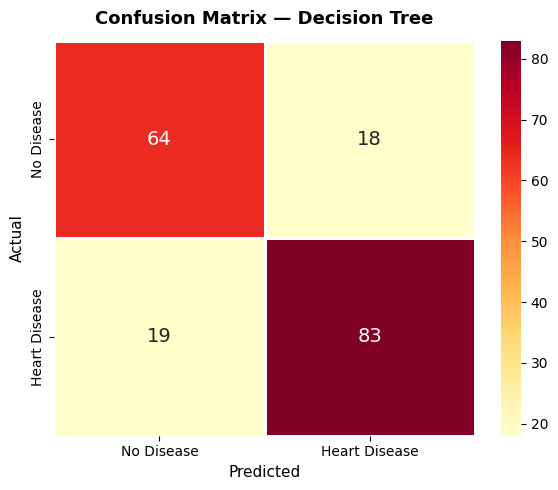

  TP=83  TN=64  FP=18  FN=19
✅ Decision Tree model saved!


In [13]:
print("🟢 Training Decision Tree...")

dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
    criterion='gini'
)

dt_results = evaluate_model(
    'Decision Tree',
    dt_model,
    X_train_scaled, X_test_scaled,
    y_train, y_test
)

plot_confusion_matrix(
    y_test, dt_results['y_pred'],
    'Decision Tree', 'YlOrRd'
)

# Save model
with open(os.path.join(MODELS_PATH, 'dt_model.pkl'), 'wb') as f:
    pickle.dump(dt_model, f)
print("✅ Decision Tree model saved!")

CELL 10 — ROC Curves — All Models

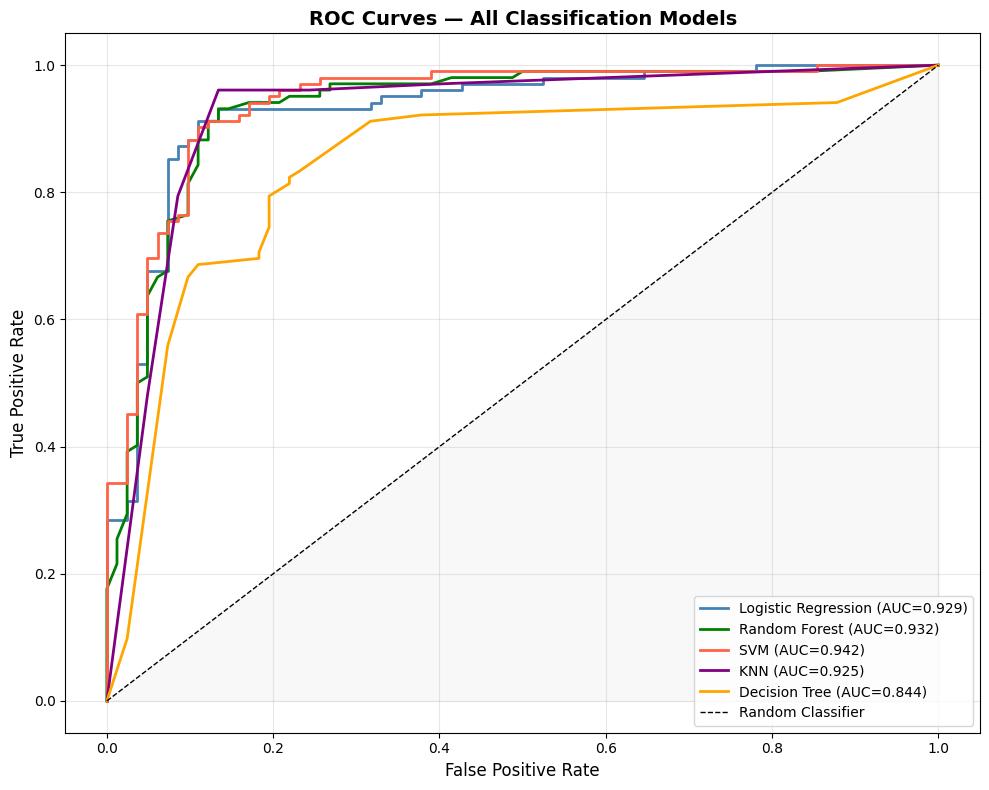

✅ ROC curves saved!


In [14]:
all_results = [lr_results, rf_results,
               svm_results, knn_results, dt_results]
colors      = ['steelblue', 'green', 'tomato',
               'purple', 'orange']

plt.figure(figsize=(10, 8))

for res, color in zip(all_results, colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr,
             label=f"{res['Model']} (AUC={res['ROC_AUC']:.3f})",
             color=color, linewidth=2)

plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Classifier')
plt.fill_between([0,1], [0,1], alpha=0.05, color='gray')

plt.title('ROC Curves — All Classification Models',
          fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_all_models.png', dpi=150)
plt.show()
plt.close()
print("✅ ROC curves saved!")

CELL 11 — All Confusion Matrices Together

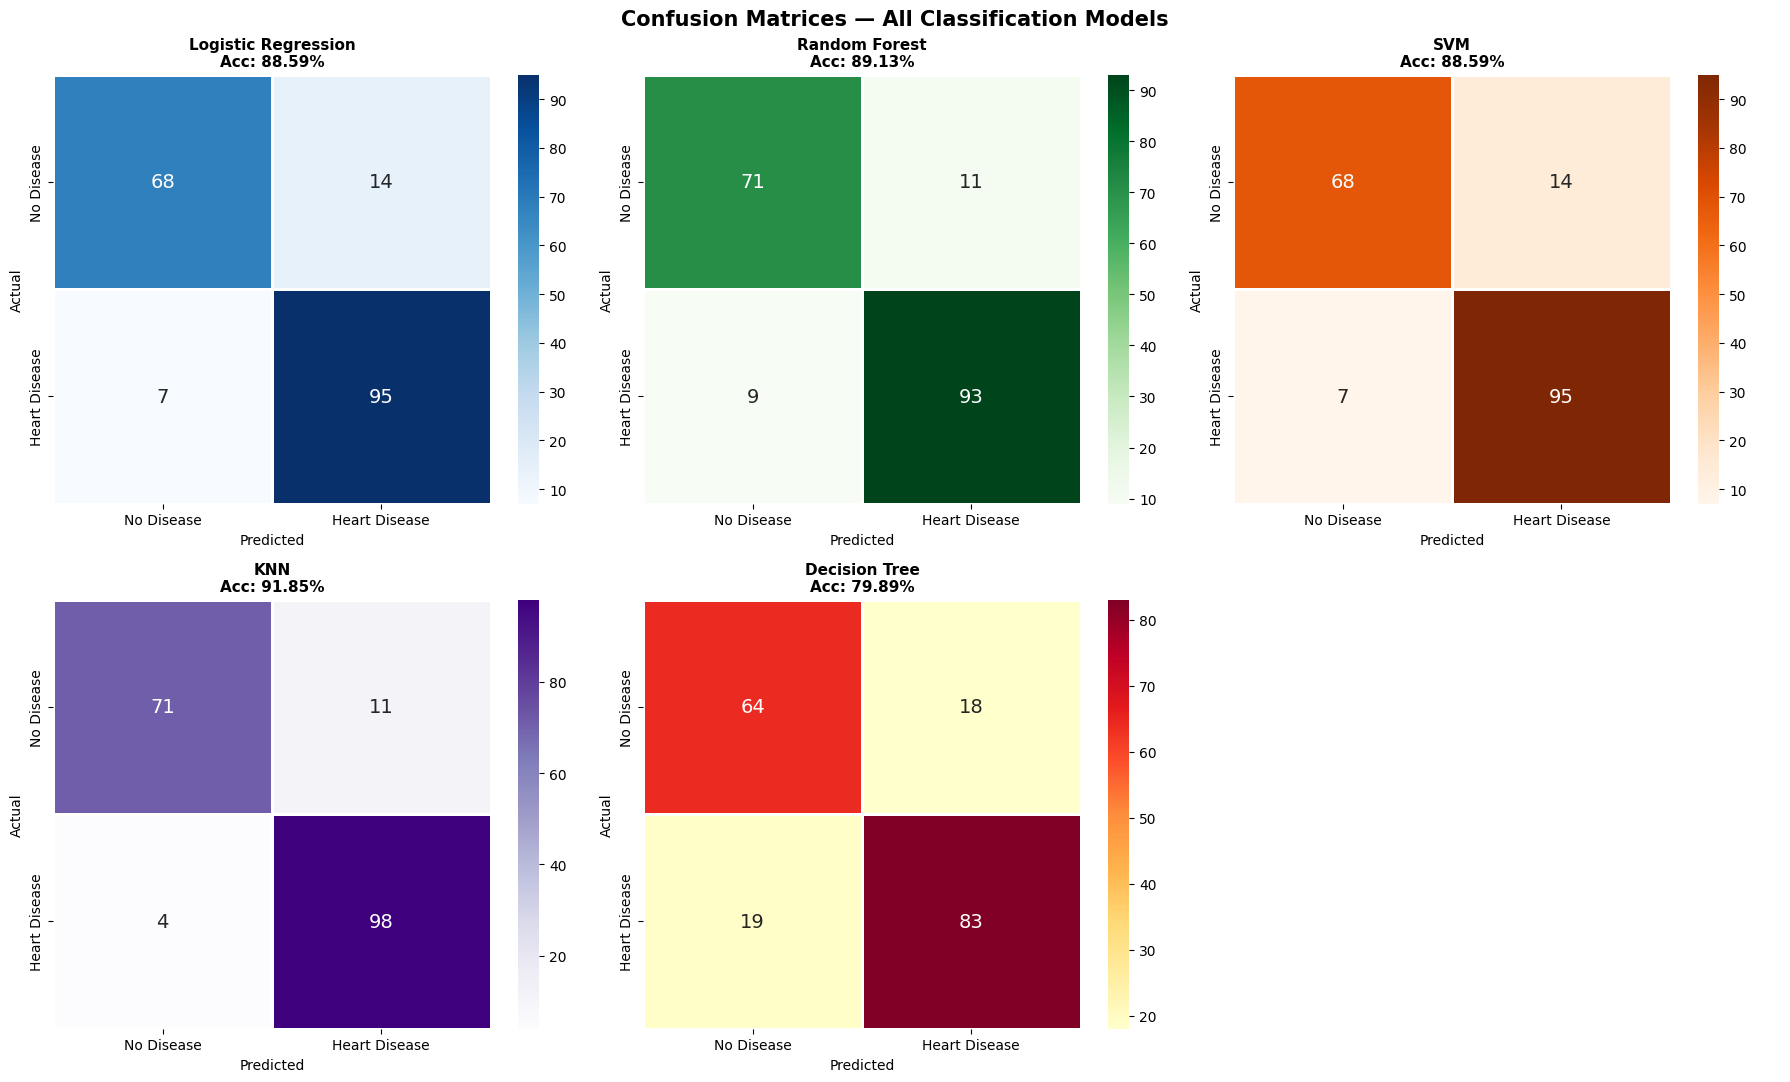

✅ All confusion matrices saved!


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes      = axes.flatten()
cmaps     = ['Blues','Greens','Oranges','Purples','YlOrRd']
names     = ['Logistic Regression','Random Forest',
             'SVM','KNN','Decision Tree']

for i, (res, cmap) in enumerate(zip(all_results, cmaps)):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=['No Disease','Heart Disease'],
                yticklabels=['No Disease','Heart Disease'],
                linewidths=1, linecolor='white',
                annot_kws={"size": 14}, ax=axes[i])
    axes[i].set_title(f"{res['Model']}\nAcc: {res['Accuracy']}%",
                       fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

# Hide last empty subplot
axes[5].axis('off')

plt.suptitle('Confusion Matrices — All Classification Models',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("✅ All confusion matrices saved!")

CELL 12 — Classification Models Comparison

CLASSIFICATION MODELS — FINAL COMPARISON
              Model  Accuracy  Precision  Recall  F1_Score  ROC_AUC
                KNN     91.85     0.8991  0.9608    0.9289   0.9252
      Random Forest     89.13     0.8942  0.9118    0.9029   0.9319
Logistic Regression     88.59     0.8716  0.9314    0.9005   0.9295
                SVM     88.59     0.8716  0.9314    0.9005   0.9420
      Decision Tree     79.89     0.8218  0.8137    0.8177   0.8440

🏆 Best Model: KNN (91.85%)


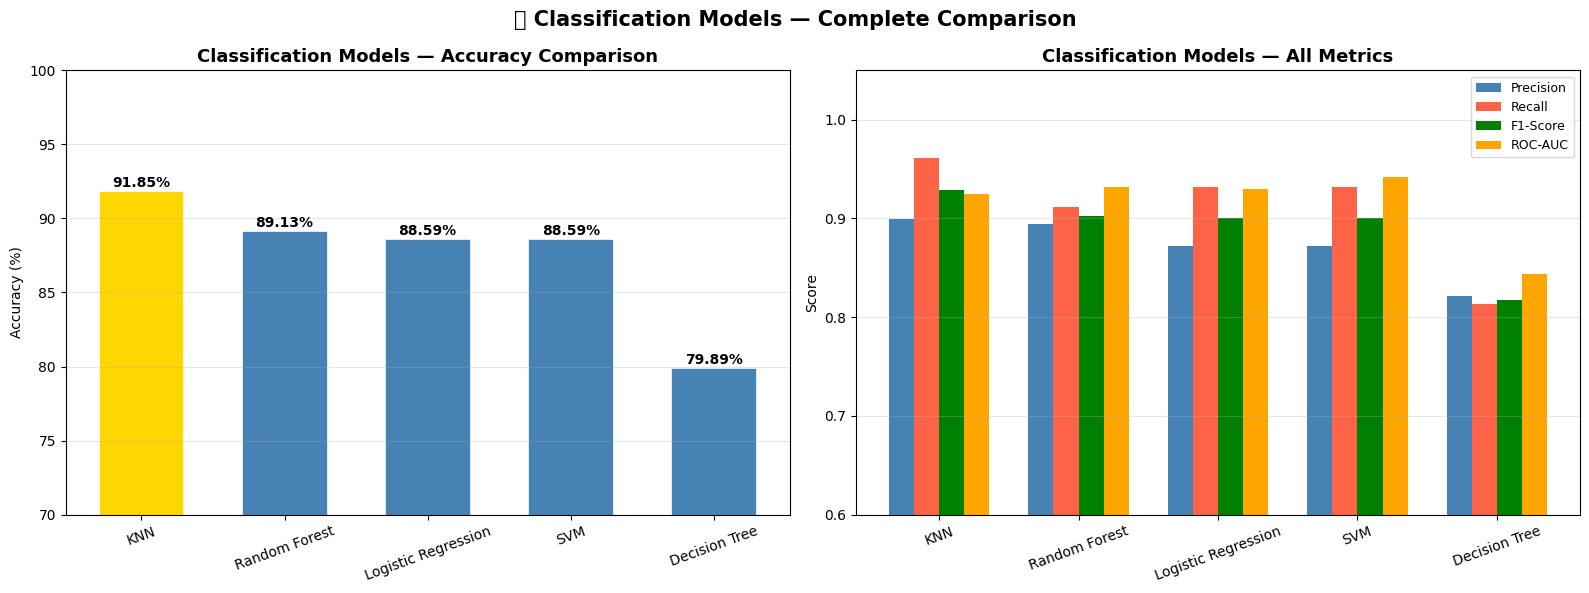

✅ Classification comparison saved!


In [16]:
# Build comparison dataframe
df_compare = pd.DataFrame([{
    'Model'    : r['Model'],
    'Accuracy' : r['Accuracy'],
    'Precision': r['Precision'],
    'Recall'   : r['Recall'],
    'F1_Score' : r['F1_Score'],
    'ROC_AUC'  : r['ROC_AUC']
} for r in all_results])

df_compare = df_compare.sort_values('Accuracy', ascending=False)

print("=" * 70)
print("CLASSIFICATION MODELS — FINAL COMPARISON")
print("=" * 70)
print(df_compare.to_string(index=False))
print("=" * 70)
print(f"\n🏆 Best Model: {df_compare.iloc[0]['Model']} "
      f"({df_compare.iloc[0]['Accuracy']}%)")

# ── Graph 1: Accuracy Bar Chart ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors    = ['gold' if i == 0 else 'steelblue'
             for i in range(len(df_compare))]

bars = axes[0].bar(
    df_compare['Model'],
    df_compare['Accuracy'],
    color=colors,
    edgecolor='white',
    linewidth=1.2,
    width=0.6
)
axes[0].set_title('Classification Models — Accuracy Comparison',
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(70, 100)
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, df_compare['Accuracy']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val}%',
                 ha='center', fontweight='bold', fontsize=10)

# ── Graph 2: Multi-Metric Comparison ──
x     = np.arange(len(df_compare))
width = 0.18

axes[1].bar(x - width*1.5, df_compare['Precision'],
            width, label='Precision', color='steelblue')
axes[1].bar(x - width*0.5, df_compare['Recall'],
            width, label='Recall',    color='tomato')
axes[1].bar(x + width*0.5, df_compare['F1_Score'],
            width, label='F1-Score',  color='green')
axes[1].bar(x + width*1.5, df_compare['ROC_AUC'],
            width, label='ROC-AUC',   color='orange')

axes[1].set_title('Classification Models — All Metrics',
                   fontsize=13, fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0.6, 1.05)
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_compare['Model'], rotation=20)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('📊 Classification Models — Complete Comparison',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('classification_comparison.png', dpi=150,
            bbox_inches='tight')
plt.show()
plt.close()
print("✅ Classification comparison saved!")

CELL 13 — Best Classification Model Summary

In [17]:
best_model_name   = df_compare.iloc[0]['Model']
best_model_object = {
    'Logistic Regression': lr_model,
    'Random Forest'      : rf_model,
    'SVM'                : svm_model,
    'KNN'                : knn_model,
    'Decision Tree'      : dt_model,
}[best_model_name]

print("=" * 55)
print(f"🏆 BEST CLASSIFICATION MODEL: {best_model_name}")
print("=" * 55)
print(f"  Accuracy  : {df_compare.iloc[0]['Accuracy']}%")
print(f"  Precision : {df_compare.iloc[0]['Precision']}")
print(f"  Recall    : {df_compare.iloc[0]['Recall']}")
print(f"  F1-Score  : {df_compare.iloc[0]['F1_Score']}")
print(f"  ROC-AUC   : {df_compare.iloc[0]['ROC_AUC']}")

# Save best classification model separately
with open(os.path.join(MODELS_PATH, 'best_classifier.pkl'), 'wb') as f:
    pickle.dump(best_model_object, f)
print(f"\n✅ Best classifier saved as best_classifier.pkl!")

🏆 BEST CLASSIFICATION MODEL: KNN
  Accuracy  : 91.85%
  Precision : 0.8991
  Recall    : 0.9608
  F1-Score  : 0.9289
  ROC-AUC   : 0.9252

✅ Best classifier saved as best_classifier.pkl!


CLUSTERING SECTION


CELL 14 — Clustering Data Preparation

In [18]:
# Use numerical features only for clustering
cluster_features = ['Age', 'RestingBP', 'Cholesterol',
                    'FastingBS', 'MaxHR', 'Oldpeak']

X_cluster = df[cluster_features].copy()

# Normalize for clustering
scaler_cluster = MinMaxScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print("Clustering Features:")
for f in cluster_features:
    print(f"  • {f}")
print(f"\nShape: {X_cluster_scaled.shape}")
print("✅ Clustering data ready!")

Clustering Features:
  • Age
  • RestingBP
  • Cholesterol
  • FastingBS
  • MaxHR
  • Oldpeak

Shape: (918, 6)
✅ Clustering data ready!


 CELL 15 — Elbow Method (Find Optimal K)

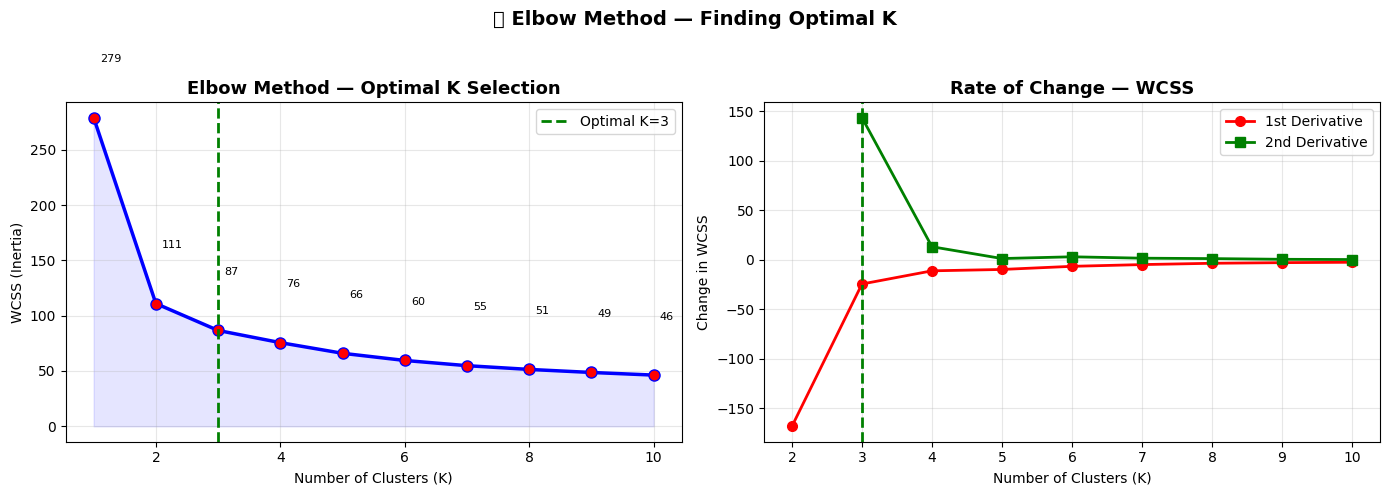

✅ Elbow method graph saved!
✅ Optimal K = 3 selected


In [19]:
wcss   = []
k_vals = range(1, 11)

for k in k_vals:
    km = KMeans(n_clusters=k, random_state=42,
                n_init=10, max_iter=300)
    km.fit(X_cluster_scaled)
    wcss.append(km.inertia_)

# Plot Elbow
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1: WCSS Line
axes[0].plot(k_vals, wcss, 'bo-',
             linewidth=2.5, markersize=8,
             markerfacecolor='red')
axes[0].axvline(x=3, color='green', linestyle='--',
                linewidth=2, label='Optimal K=3')
axes[0].fill_between(k_vals, wcss, alpha=0.1, color='blue')
axes[0].set_title('Elbow Method — Optimal K Selection',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('WCSS (Inertia)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
for i, (k, w) in enumerate(zip(k_vals, wcss)):
    axes[0].annotate(f'{w:.0f}',
                     xy=(k, w), xytext=(k+0.1, w+50),
                     fontsize=8)

# Graph 2: Rate of Change
diff  = np.diff(wcss)
diff2 = np.diff(diff)
axes[1].plot(range(2, 11), diff,  'ro-',
             linewidth=2, label='1st Derivative',
             markersize=7)
axes[1].plot(range(3, 11), diff2, 'gs-',
             linewidth=2, label='2nd Derivative',
             markersize=7)
axes[1].set_title('Rate of Change — WCSS',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Change in WCSS')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=3, color='green', linestyle='--',
                linewidth=2, label='K=3')

plt.suptitle('📊 Elbow Method — Finding Optimal K',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

print("✅ Elbow method graph saved!")
print("✅ Optimal K = 3 selected")

CELL 16 — K-Means Clustering

K-MEANS CLUSTERING RESULTS

Cluster 0 — Low Risk:
  Patients    : 214
  Avg Age     : 56.9
  Avg BP      : 134.8
  Avg Chol    : 147.1
  Avg MaxHR   : 130.7
  Heart Disease: 79.4%

Cluster 1 — Medium Risk:
  Patients    : 360
  Avg Age     : 58.8
  Avg BP      : 135.9
  Avg Chol    : 194.3
  Avg MaxHR   : 122.3
  Heart Disease: 66.9%

Cluster 2 — High Risk:
  Patients    : 344
  Avg Age     : 45.9
  Avg BP      : 127.3
  Avg Chol    : 235.7
  Avg MaxHR   : 155.8
  Heart Disease: 28.2%


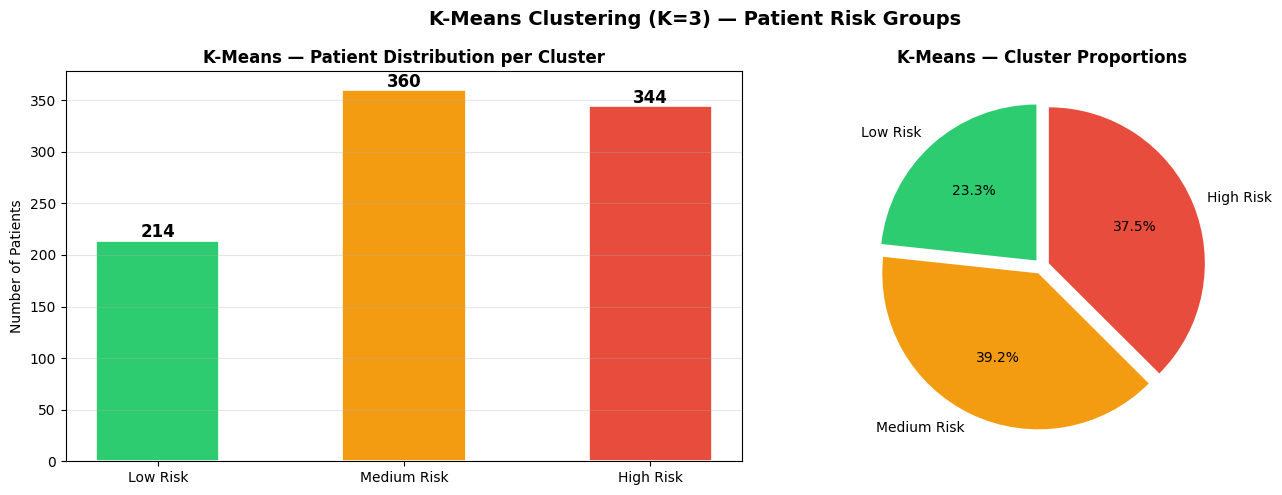


✅ K-Means model saved!


In [20]:
# Apply K-Means with K=3
OPTIMAL_K = 3

kmeans = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=42,
    n_init=10,
    max_iter=300
)
kmeans.fit(X_cluster_scaled)
cluster_labels = kmeans.labels_

# Add cluster to dataframe
df_clustered = df.copy()
df_clustered['Cluster'] = cluster_labels

# Map clusters to risk levels
cluster_risk_map = {0: 'Low Risk',
                    1: 'Medium Risk',
                    2: 'High Risk'}

# Analyze clusters
print("=" * 55)
print("K-MEANS CLUSTERING RESULTS")
print("=" * 55)
for i in range(OPTIMAL_K):
    cluster_data = df_clustered[df_clustered['Cluster'] == i]
    print(f"\nCluster {i} — {cluster_risk_map[i]}:")
    print(f"  Patients    : {len(cluster_data)}")
    print(f"  Avg Age     : {cluster_data['Age'].mean():.1f}")
    print(f"  Avg BP      : {cluster_data['RestingBP'].mean():.1f}")
    print(f"  Avg Chol    : {cluster_data['Cholesterol'].mean():.1f}")
    print(f"  Avg MaxHR   : {cluster_data['MaxHR'].mean():.1f}")
    heart_pct = cluster_data['HeartDisease'].mean() * 100
    print(f"  Heart Disease: {heart_pct:.1f}%")

# Cluster Distribution Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors    = ['#2ecc71', '#f39c12', '#e74c3c']
labels    = [cluster_risk_map[i] for i in range(OPTIMAL_K)]
counts    = [sum(cluster_labels == i) for i in range(OPTIMAL_K)]

bars = axes[0].bar(labels, counts, color=colors,
                   edgecolor='white', linewidth=1.2, width=0.5)
axes[0].set_title('K-Means — Patient Distribution per Cluster',
                   fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Patients')
axes[0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 3,
                 str(val), ha='center',
                 fontweight='bold', fontsize=12)

axes[1].pie(counts, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            explode=(0.05, 0.05, 0.05))
axes[1].set_title('K-Means — Cluster Proportions',
                   fontsize=12, fontweight='bold')

plt.suptitle('K-Means Clustering (K=3) — Patient Risk Groups',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_distribution.png', dpi=150)
plt.show()
plt.close()

# Save KMeans model
with open(os.path.join(MODELS_PATH, 'kmeans_model.pkl'), 'wb') as f:
    pickle.dump(kmeans, f)
print("\n✅ K-Means model saved!")

CELL 17 — PCA Visualization


PCA Explained Variance:
  PC1: 60.7%
  PC2: 15.8%
  Total: 76.5%


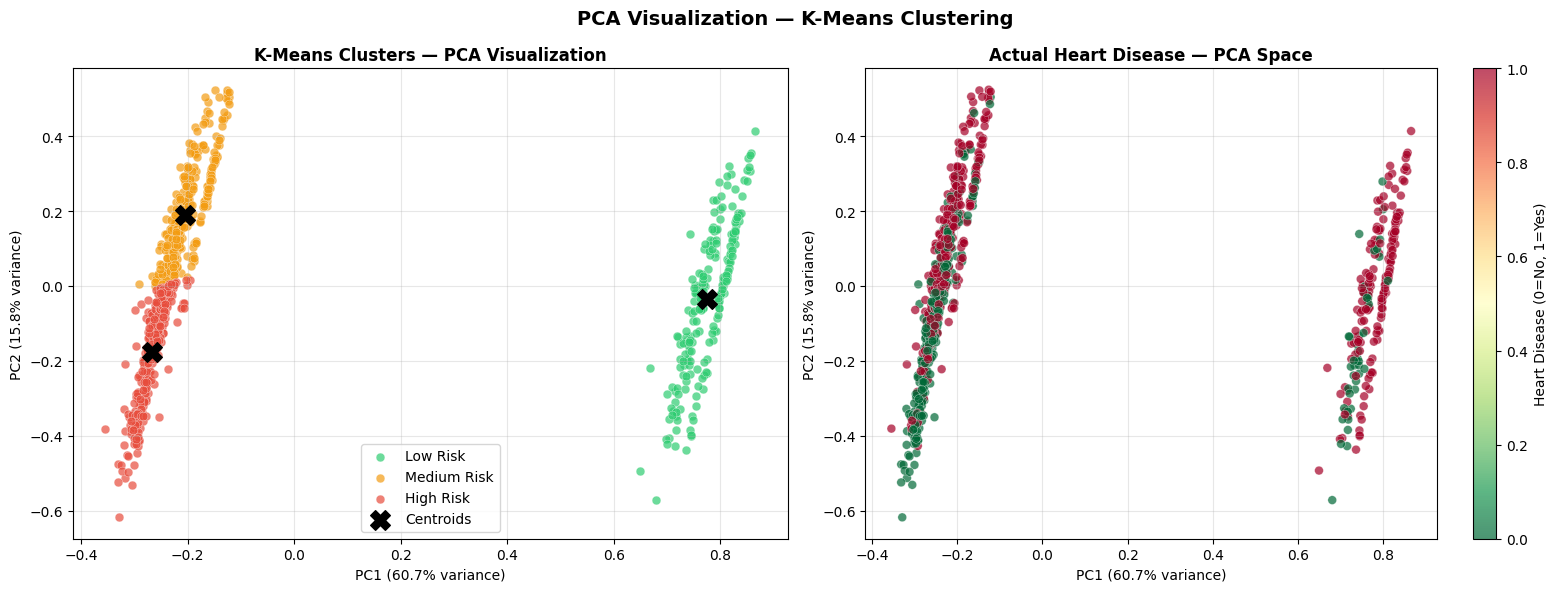

✅ PCA graph saved!


In [21]:
# Apply PCA to reduce to 2D
pca        = PCA(n_components=2, random_state=42)
X_pca      = pca.fit_transform(X_cluster_scaled)
explained  = pca.explained_variance_ratio_

print(f"PCA Explained Variance:")
print(f"  PC1: {explained[0]*100:.1f}%")
print(f"  PC2: {explained[1]*100:.1f}%")
print(f"  Total: {sum(explained)*100:.1f}%")

# Plot PCA clusters
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors    = ['#2ecc71', '#f39c12', '#e74c3c']

# Graph 1: K-Means clusters in PCA space
for i in range(OPTIMAL_K):
    mask = cluster_labels == i
    axes[0].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[i], label=cluster_risk_map[i],
        alpha=0.7, s=40, edgecolors='white', linewidth=0.3
    )

# Plot centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    c='black', marker='X', s=200,
    zorder=5, label='Centroids'
)
axes[0].set_title('K-Means Clusters — PCA Visualization',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graph 2: Actual heart disease in PCA space
scatter = axes[1].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=df['HeartDisease'],
    cmap='RdYlGn_r',
    alpha=0.7, s=40,
    edgecolors='white', linewidth=0.3
)
plt.colorbar(scatter, ax=axes[1],
             label='Heart Disease (0=No, 1=Yes)')
axes[1].set_title('Actual Heart Disease — PCA Space',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('PCA Visualization — K-Means Clustering',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("✅ PCA graph saved!")

CELL 18 — Hierarchical Clustering


🔵 Hierarchical Clustering...


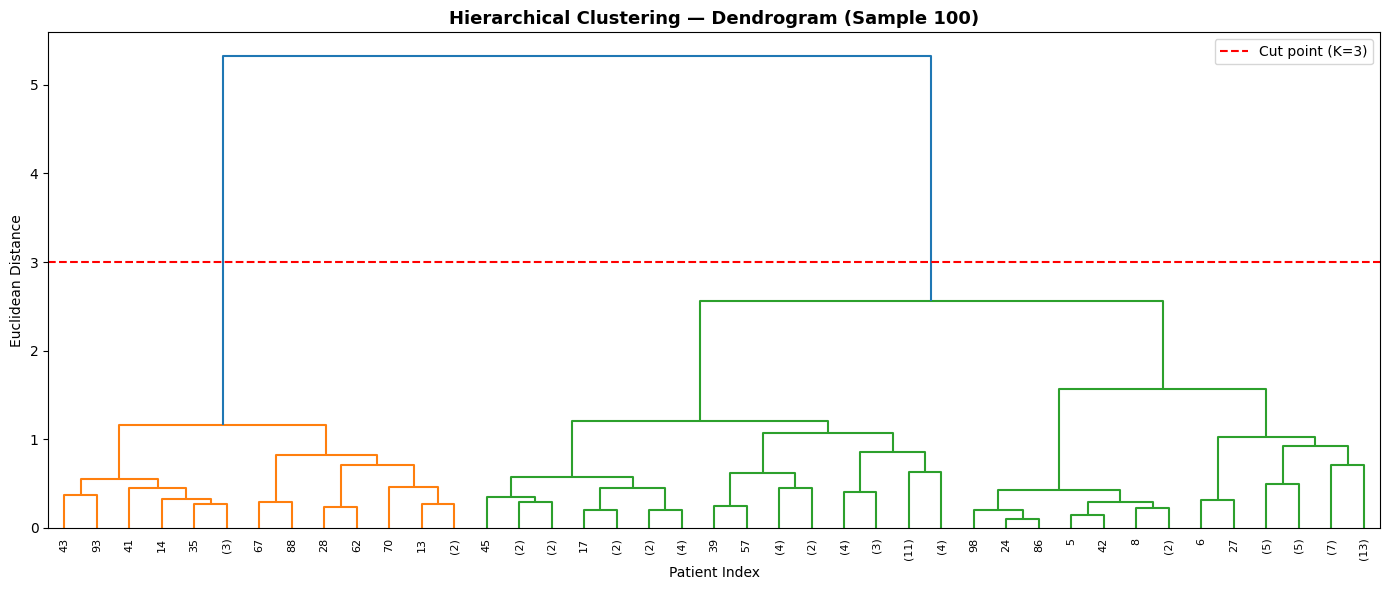

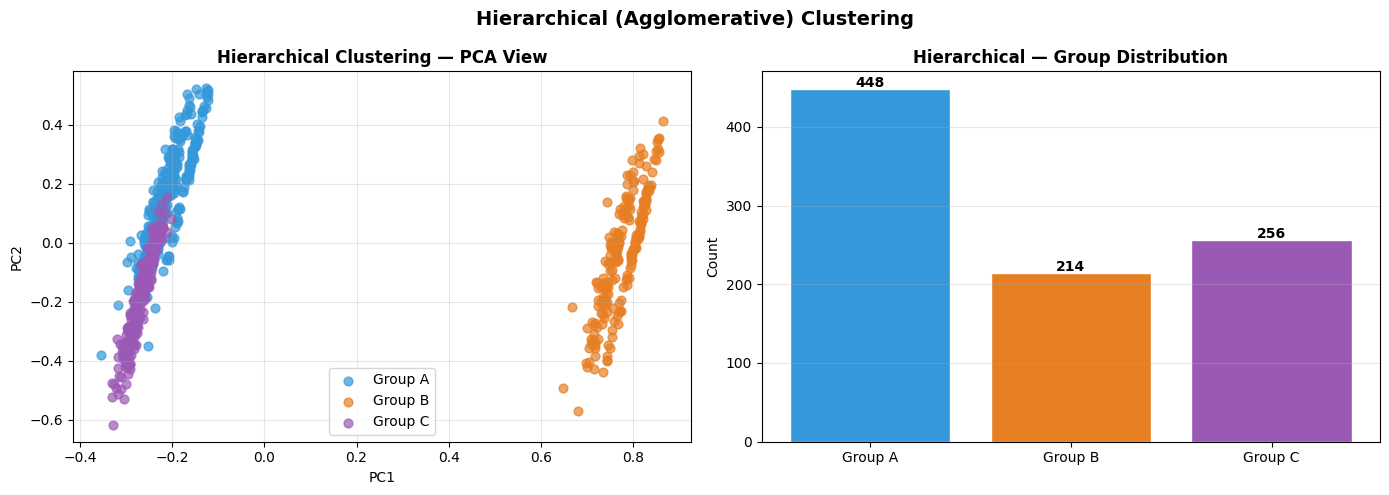

✅ Hierarchical clustering done!


In [22]:
from scipy.cluster.hierarchy import dendrogram, linkage

print("🔵 Hierarchical Clustering...")

# Dendrogram (sample 100 for visibility)
sample_idx   = np.random.choice(len(X_cluster_scaled),
                                 100, replace=False)
X_sample     = X_cluster_scaled[sample_idx]
linked       = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(
    linked,
    truncate_mode='level',
    p=5,
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=3
)
plt.title('Hierarchical Clustering — Dendrogram (Sample 100)',
          fontsize=13, fontweight='bold')
plt.xlabel('Patient Index')
plt.ylabel('Euclidean Distance')
plt.axhline(y=3, color='red', linestyle='--',
            label='Cut point (K=3)')
plt.legend()
plt.tight_layout()
plt.savefig('hierarchical_dendrogram.png', dpi=150)
plt.show()
plt.close()

# Apply Agglomerative Clustering
hc_model = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)
hc_labels = hc_model.fit_predict(X_cluster_scaled)

# PCA visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors    = ['#3498db', '#e67e22', '#9b59b6']
labels    = ['Group A', 'Group B', 'Group C']

for i in range(3):
    mask = hc_labels == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors[i], label=labels[i],
                    alpha=0.7, s=40)
axes[0].set_title('Hierarchical Clustering — PCA View',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribution
hc_counts = [sum(hc_labels == i) for i in range(3)]
axes[1].bar(labels, hc_counts, color=colors,
            edgecolor='white')
axes[1].set_title('Hierarchical — Group Distribution',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
for i, (bar, val) in enumerate(zip(axes[1].patches, hc_counts)):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 3,
                 str(val), ha='center', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Hierarchical (Agglomerative) Clustering',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hierarchical_clustering.png', dpi=150)
plt.show()
plt.close()
print("✅ Hierarchical clustering done!")

CELL 19 — DBSCAN Clustering

🟠 DBSCAN Clustering...
DBSCAN — eps parameter analysis:
 eps  clusters  noise_points
 0.1         9           589
 0.2         3            52
 0.3         2             5
 0.4         2             1
 0.5         2             0
 0.6         2             0
 0.7         2             0

DBSCAN Results (eps=0.5, min_samples=5):
  Clusters found  : 2
  Noise points    : 0
  Core points     : 918


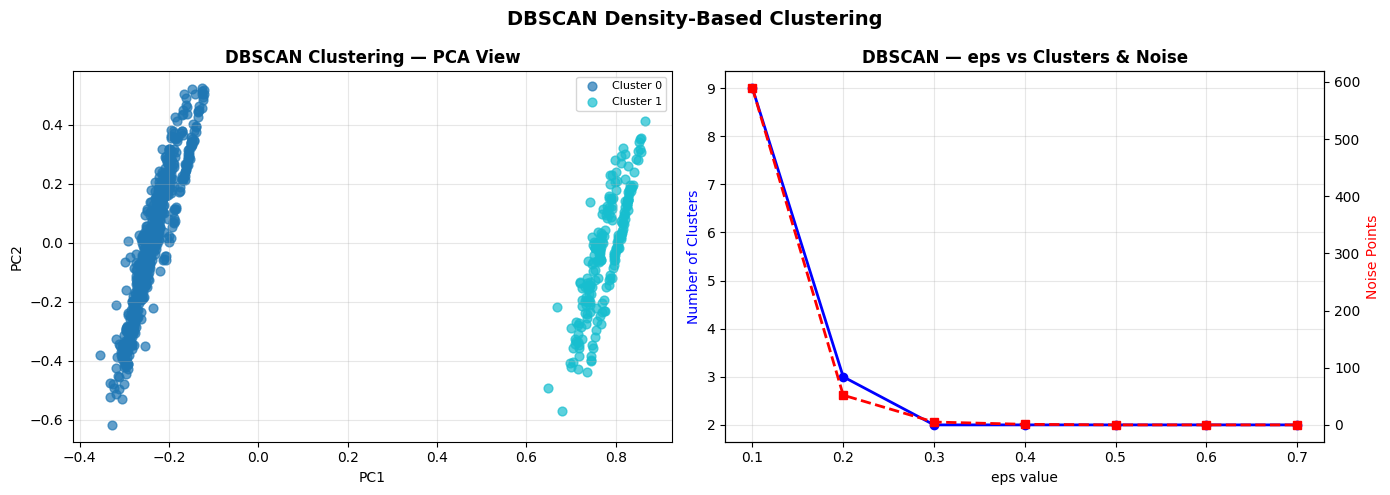

✅ DBSCAN clustering done!


In [23]:
from sklearn.metrics import silhouette_score

print("🟠 DBSCAN Clustering...")

# Find best eps
eps_scores = []
eps_vals   = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

for eps in eps_vals:
    db    = DBSCAN(eps=eps, min_samples=5)
    lbs   = db.fit_predict(X_cluster_scaled)
    n_cls = len(set(lbs)) - (1 if -1 in lbs else 0)
    noise = list(lbs).count(-1)
    eps_scores.append({
        'eps': eps,
        'clusters': n_cls,
        'noise_points': noise
    })

df_eps = pd.DataFrame(eps_scores)
print("DBSCAN — eps parameter analysis:")
print(df_eps.to_string(index=False))

# Apply DBSCAN with best eps
dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(X_cluster_scaled)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = list(db_labels).count(-1)

print(f"\nDBSCAN Results (eps=0.5, min_samples=5):")
print(f"  Clusters found  : {n_clusters}")
print(f"  Noise points    : {n_noise}")
print(f"  Core points     : {len(db_labels) - n_noise}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Unique labels
unique_labels = set(db_labels)
palette       = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(sorted(unique_labels), palette):
    mask       = db_labels == k
    label_name = 'Noise' if k == -1 else f'Cluster {k}'
    marker     = 'x' if k == -1 else 'o'
    alpha_val  = 0.3 if k == -1 else 0.7
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=[col], label=label_name,
                    marker=marker, s=40, alpha=alpha_val)

axes[0].set_title('DBSCAN Clustering — PCA View',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# eps vs clusters
axes[1].plot(df_eps['eps'], df_eps['clusters'],
             'bo-', linewidth=2, label='Clusters')
ax2 = axes[1].twinx()
ax2.plot(df_eps['eps'], df_eps['noise_points'],
         'rs--', linewidth=2, label='Noise Points')
axes[1].set_title('DBSCAN — eps vs Clusters & Noise',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('eps value')
axes[1].set_ylabel('Number of Clusters', color='blue')
ax2.set_ylabel('Noise Points', color='red')
axes[1].grid(True, alpha=0.3)

plt.suptitle('DBSCAN Density-Based Clustering',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dbscan_clustering.png', dpi=150)
plt.show()
plt.close()
print("✅ DBSCAN clustering done!")

 CELL 20 — K-Medoids Clustering

🟣 K-Medoids Clustering...
K-Medoids Results:
  Cluster 0: 325 patients
  Cluster 1: 379 patients
  Cluster 2: 214 patients


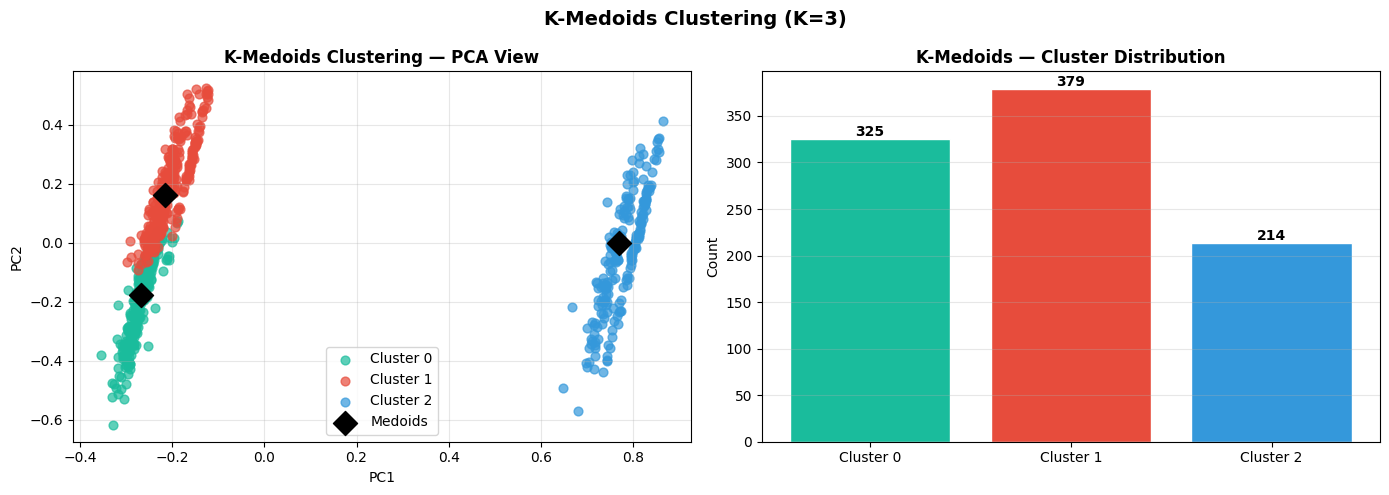

✅ K-Medoids clustering done!


In [24]:
# K-Medoids implementation (manual — no extra library needed)
print("🟣 K-Medoids Clustering...")

from sklearn.metrics import pairwise_distances

def kmedoids(X, k, max_iter=100, random_state=42):
    np.random.seed(random_state)
    n         = X.shape[0]
    medoid_idx = np.random.choice(n, k, replace=False)
    labels    = np.zeros(n, dtype=int)

    for _ in range(max_iter):
        # Assign points to nearest medoid
        distances = pairwise_distances(X, X[medoid_idx])
        labels    = np.argmin(distances, axis=1)

        new_medoids = medoid_idx.copy()
        for j in range(k):
            cluster_pts = np.where(labels == j)[0]
            if len(cluster_pts) == 0:
                continue
            intra_dist = pairwise_distances(
                X[cluster_pts]).sum(axis=1)
            new_medoids[j] = cluster_pts[np.argmin(intra_dist)]

        if np.all(new_medoids == medoid_idx):
            break
        medoid_idx = new_medoids

    return labels, medoid_idx


km_labels, km_medoids = kmedoids(X_cluster_scaled, k=3)

print(f"K-Medoids Results:")
for i in range(3):
    count = sum(km_labels == i)
    print(f"  Cluster {i}: {count} patients")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors    = ['#1abc9c', '#e74c3c', '#3498db']

for i in range(3):
    mask = km_labels == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors[i],
                    label=f'Cluster {i}',
                    alpha=0.7, s=40)

# Plot medoids
medoid_pca = pca.transform(X_cluster_scaled[km_medoids])
axes[0].scatter(medoid_pca[:, 0], medoid_pca[:, 1],
                c='black', marker='D', s=150,
                zorder=5, label='Medoids')
axes[0].set_title('K-Medoids Clustering — PCA View',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

kmed_counts = [sum(km_labels == i) for i in range(3)]
axes[1].bar([f'Cluster {i}' for i in range(3)],
            kmed_counts, color=colors,
            edgecolor='white')
axes[1].set_title('K-Medoids — Cluster Distribution',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
for bar, val in zip(axes[1].patches, kmed_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 3,
                 str(val), ha='center', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('K-Medoids Clustering (K=3)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('kmedoids_clustering.png', dpi=150)
plt.show()
plt.close()
print("✅ K-Medoids clustering done!")

CELL 21 — All Clustering Comparison

CLUSTERING METHODS — METRIC COMPARISON

K-Means:
  Silhouette Score      : 0.3291 (higher=better)
  Davies-Bouldin Score  : 1.1684  (lower=better)
  Calinski-Harabasz     : 1015.92   (higher=better)

Hierarchical:
  Silhouette Score      : 0.2851 (higher=better)
  Davies-Bouldin Score  : 1.2444  (lower=better)
  Calinski-Harabasz     : 936.06   (higher=better)

DBSCAN:
  Silhouette Score      : 0.5930 (higher=better)
  Davies-Bouldin Score  : 0.6623  (lower=better)
  Calinski-Harabasz     : 1387.21   (higher=better)

K-Medoids:
  Silhouette Score      : 0.3251 (higher=better)
  Davies-Bouldin Score  : 1.1737  (lower=better)
  Calinski-Harabasz     : 1006.38   (higher=better)


      Method  Clusters  Silhouette  Davies_Bouldin  Calinski_Harabasz
     K-Means         3      0.3291          1.1684            1015.92
Hierarchical         3      0.2851          1.2444             936.06
      DBSCAN         2      0.5930          0.6623            1387.21
   K-Medoids         3      0.3251

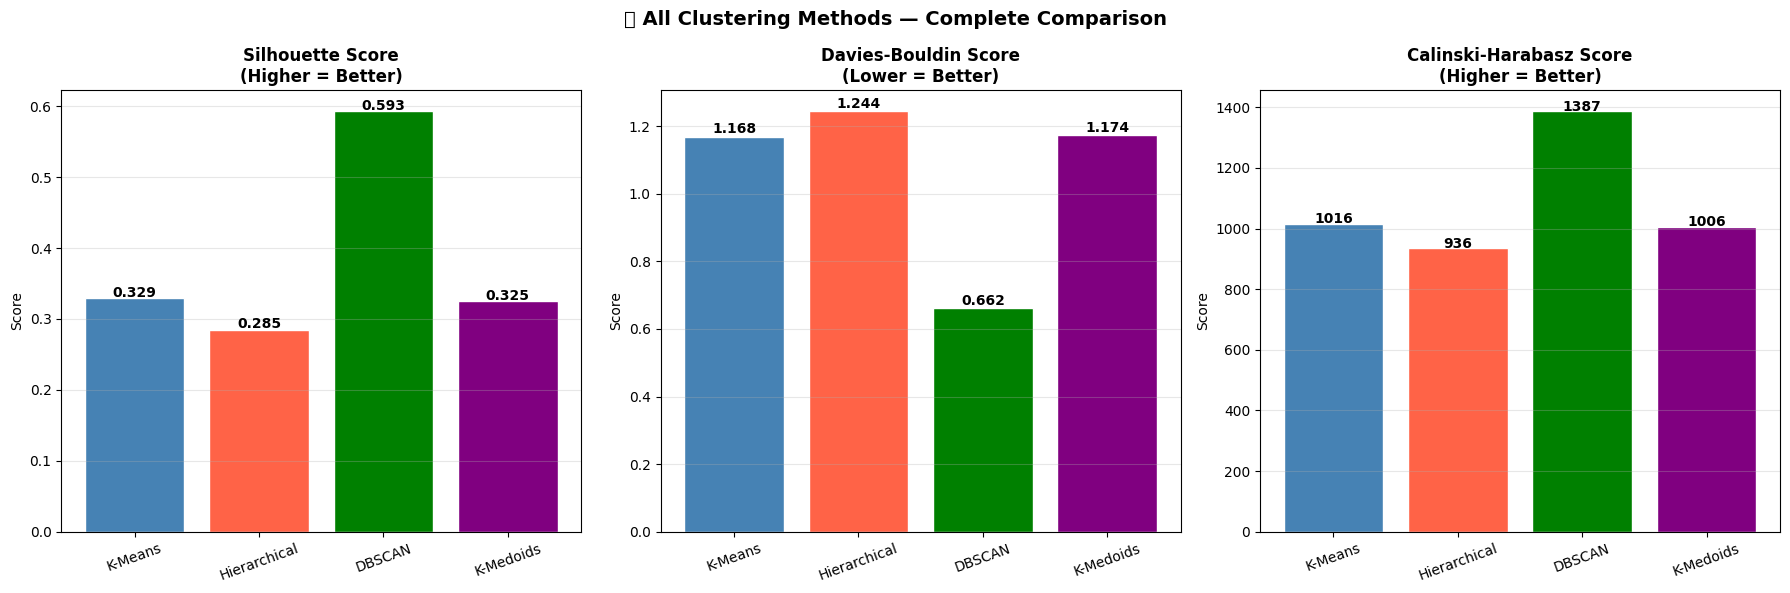


✅ Clustering comparison saved!


In [25]:
from sklearn.metrics import (silhouette_score,
                              davies_bouldin_score,
                              calinski_harabasz_score)

def clustering_metrics(X, labels, name):
    valid = len(set(labels) - {-1})
    if valid < 2:
        return {'Method': name,
                'Clusters': valid,
                'Silhouette': 0,
                'Davies_Bouldin': 999,
                'Calinski_Harabasz': 0}

    # Exclude noise for DBSCAN
    mask = labels != -1
    Xv   = X[mask]
    lv   = labels[mask]

    sil = silhouette_score(Xv, lv)
    db  = davies_bouldin_score(Xv, lv)
    ch  = calinski_harabasz_score(Xv, lv)

    print(f"\n{name}:")
    print(f"  Silhouette Score      : {sil:.4f} (higher=better)")
    print(f"  Davies-Bouldin Score  : {db:.4f}  (lower=better)")
    print(f"  Calinski-Harabasz     : {ch:.2f}   (higher=better)")

    return {'Method'            : name,
            'Clusters'          : valid,
            'Silhouette'        : round(sil, 4),
            'Davies_Bouldin'    : round(db, 4),
            'Calinski_Harabasz' : round(ch, 2)}


print("=" * 60)
print("CLUSTERING METHODS — METRIC COMPARISON")
print("=" * 60)

cluster_comparison = [
    clustering_metrics(X_cluster_scaled, cluster_labels, 'K-Means'),
    clustering_metrics(X_cluster_scaled, hc_labels,      'Hierarchical'),
    clustering_metrics(X_cluster_scaled, db_labels,      'DBSCAN'),
    clustering_metrics(X_cluster_scaled, km_labels,      'K-Medoids'),
]

df_cluster_compare = pd.DataFrame(cluster_comparison)
print("\n")
print(df_cluster_compare.to_string(index=False))

# ── Comparison Graphs ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
clr_colors = ['steelblue','tomato','green','purple']

# Silhouette (higher better)
axes[0].bar(df_cluster_compare['Method'],
            df_cluster_compare['Silhouette'],
            color=clr_colors, edgecolor='white')
axes[0].set_title('Silhouette Score\n(Higher = Better)',
                   fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(axes[0].patches,
                    df_cluster_compare['Silhouette']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{val:.3f}', ha='center',
                 fontweight='bold', fontsize=10)

# Davies-Bouldin (lower better)
axes[1].bar(df_cluster_compare['Method'],
            df_cluster_compare['Davies_Bouldin'],
            color=clr_colors, edgecolor='white')
axes[1].set_title('Davies-Bouldin Score\n(Lower = Better)',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(axes[1].patches,
                    df_cluster_compare['Davies_Bouldin']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center',
                 fontweight='bold', fontsize=10)

# Calinski-Harabasz (higher better)
axes[2].bar(df_cluster_compare['Method'],
            df_cluster_compare['Calinski_Harabasz'],
            color=clr_colors, edgecolor='white')
axes[2].set_title('Calinski-Harabasz Score\n(Higher = Better)',
                   fontsize=12, fontweight='bold')
axes[2].set_ylabel('Score')
axes[2].tick_params(axis='x', rotation=20)
axes[2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(axes[2].patches,
                    df_cluster_compare['Calinski_Harabasz']):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{val:.0f}', ha='center',
                 fontweight='bold', fontsize=10)

plt.suptitle('📊 All Clustering Methods — Complete Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('clustering_comparison.png', dpi=150,
            bbox_inches='tight')
plt.show()
plt.close()
print("\n✅ Clustering comparison saved!")

CELL 22 — Best Clustering Method & Final Summary

In [26]:
best_cluster = df_cluster_compare.loc[
    df_cluster_compare['Silhouette'].idxmax()
]

print("=" * 55)
print(f"🏆 BEST CLUSTERING METHOD: {best_cluster['Method']}")
print("=" * 55)
print(f"  Silhouette Score     : {best_cluster['Silhouette']}")
print(f"  Davies-Bouldin Score : {best_cluster['Davies_Bouldin']}")
print(f"  Calinski-Harabasz   : {best_cluster['Calinski_Harabasz']}")

# Save clustering comparison
df_cluster_compare.to_csv('clustering_comparison.csv', index=False)
df_compare.to_csv('classification_comparison.csv', index=False)
print("\n✅ Comparison CSVs saved!")

🏆 BEST CLUSTERING METHOD: DBSCAN
  Silhouette Score     : 0.593
  Davies-Bouldin Score : 0.6623
  Calinski-Harabasz   : 1387.21

✅ Comparison CSVs saved!


CELL 23 — All PKL Files Verification


In [27]:
print("=" * 55)
print("ALL PKL FILES FOR AGENTIC AI")
print("=" * 55)

required_files = [
    'scaler.pkl',
    'feature_columns.pkl',
    'kmeans_model.pkl',
    'logistic_model.pkl',
    'rf_model.pkl',
    'svm_model.pkl',
    'knn_model.pkl',
    'dt_model.pkl',
    'best_classifier.pkl',
]

print("\nChecking files:")
for fname in required_files:
    fpath  = os.path.join(MODELS_PATH, fname)
    status = "✅ EXISTS" if os.path.exists(fpath) else "❌ MISSING"
    size   = (f"{os.path.getsize(fpath)/1024:.1f} KB"
               if os.path.exists(fpath) else "—")
    print(f"  {status} → {fname:30} {size}")

print("\n✅ All files ready for Agentic AI!")

ALL PKL FILES FOR AGENTIC AI

Checking files:
  ✅ EXISTS → scaler.pkl                     1.2 KB
  ✅ EXISTS → feature_columns.pkl            0.3 KB
  ✅ EXISTS → kmeans_model.pkl               4.3 KB
  ✅ EXISTS → logistic_model.pkl             0.8 KB
  ✅ EXISTS → rf_model.pkl                   1789.7 KB
  ✅ EXISTS → svm_model.pkl                  56.4 KB
  ✅ EXISTS → knn_model.pkl                  121.1 KB
  ✅ EXISTS → dt_model.pkl                   5.4 KB
  ✅ EXISTS → best_classifier.pkl            121.1 KB

✅ All files ready for Agentic AI!


CELL 24 — Final Project Summary


In [28]:
print("=" * 65)
print("COMPLETE PROJECT SUMMARY — CLASSIFICATION & CLUSTERING")
print("=" * 65)

print("\n📊 CLASSIFICATION RESULTS:")
print("-" * 65)
for _, row in df_compare.iterrows():
    best_mark = " 🏆" if _ == 0 else ""
    print(f"  {row['Model']:<22} Acc:{row['Accuracy']:>6}% "
          f"F1:{row['F1_Score']:.3f} "
          f"AUC:{row['ROC_AUC']:.3f}{best_mark}")

print(f"\n🏆 Best Classifier: {df_compare.iloc[0]['Model']} "
      f"({df_compare.iloc[0]['Accuracy']}%)")

print("\n📊 CLUSTERING RESULTS:")
print("-" * 65)
for _, row in df_cluster_compare.iterrows():
    best_mark = (" 🏆" if row['Method'] == best_cluster['Method']
                 else "")
    print(f"  {row['Method']:<20} "
          f"Sil:{row['Silhouette']:.4f} "
          f"DB:{row['Davies_Bouldin']:.4f} "
          f"CH:{row['Calinski_Harabasz']:.1f}{best_mark}")

print(f"\n🏆 Best Clustering: {best_cluster['Method']}")

print("\n📁 PKL FILES SAVED FOR AGENTIC AI:")
print("-" * 65)
for f in required_files:
    print(f"  ✅ {f}")

print("\n📊 GRAPHS SAVED:")
graphs = [
    'cm_*.png                  ← Individual confusion matrices',
    'all_confusion_matrices.png← All 5 together',
    'roc_all_models.png        ← ROC curves',
    'rf_feature_importance.png ← Feature importance',
    'knn_k_vs_accuracy.png     ← Best K for KNN',
    'classification_comparison.png',
    'elbow_method.png          ← Optimal K',
    'pca_kmeans.png            ← Cluster visualization',
    'kmeans_distribution.png',
    'hierarchical_dendrogram.png',
    'hierarchical_clustering.png',
    'dbscan_clustering.png',
    'kmedoids_clustering.png',
    'clustering_comparison.png ← All clustering metrics',
]
for g in graphs:
    print(f"  📈 {g}")

COMPLETE PROJECT SUMMARY — CLASSIFICATION & CLUSTERING

📊 CLASSIFICATION RESULTS:
-----------------------------------------------------------------
  KNN                    Acc: 91.85% F1:0.929 AUC:0.925
  Random Forest          Acc: 89.13% F1:0.903 AUC:0.932
  Logistic Regression    Acc: 88.59% F1:0.900 AUC:0.929 🏆
  SVM                    Acc: 88.59% F1:0.900 AUC:0.942
  Decision Tree          Acc: 79.89% F1:0.818 AUC:0.844

🏆 Best Classifier: KNN (91.85%)

📊 CLUSTERING RESULTS:
-----------------------------------------------------------------
  K-Means              Sil:0.3291 DB:1.1684 CH:1015.9
  Hierarchical         Sil:0.2851 DB:1.2444 CH:936.1
  DBSCAN               Sil:0.5930 DB:0.6623 CH:1387.2 🏆
  K-Medoids            Sil:0.3251 DB:1.1737 CH:1006.4

🏆 Best Clustering: DBSCAN

📁 PKL FILES SAVED FOR AGENTIC AI:
-----------------------------------------------------------------
  ✅ scaler.pkl
  ✅ feature_columns.pkl
  ✅ kmeans_model.pkl
  ✅ logistic_model.pkl
  ✅ rf_model.pkl
  ✅